In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import nltk
import re

from nltk.corpus import stopwords
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

nltk.download('stopwords')
print("✅ All libraries loaded!")

✅ All libraries loaded!


[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\prave\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [3]:
df = pd.read_csv('Resume.csv')

print("Shape:", df.shape)
print("\nColumns:", df.columns.tolist())
print("\nAll Categories:")
print(df['Category'].value_counts())

Shape: (2484, 4)

Columns: ['ID', 'Resume_str', 'Resume_html', 'Category']

All Categories:
Category
INFORMATION-TECHNOLOGY    120
BUSINESS-DEVELOPMENT      120
ADVOCATE                  118
CHEF                      118
FINANCE                   118
ENGINEERING               118
ACCOUNTANT                118
FITNESS                   117
AVIATION                  117
SALES                     116
HEALTHCARE                115
CONSULTANT                115
BANKING                   115
CONSTRUCTION              112
PUBLIC-RELATIONS          111
HR                        110
DESIGNER                  107
ARTS                      103
TEACHER                   102
APPAREL                    97
DIGITAL-MEDIA              96
AGRICULTURE                63
AUTOMOBILE                 36
BPO                        22
Name: count, dtype: int64


In [4]:
stop_words = set(stopwords.words('english'))

def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'[^a-z\s]', '', text)
    words = text.split()
    words = [w for w in words if w not in stop_words]
    return ' '.join(words)

df['clean_resume'] = df['Resume_str'].apply(clean_text)

print("✅ Text Cleaning Done!")
print("\nBEFORE:", df['Resume_str'].iloc[0][:150])
print("\nAFTER :", df['clean_resume'].iloc[0][:150])

✅ Text Cleaning Done!

BEFORE:          HR ADMINISTRATOR/MARKETING ASSOCIATE

HR ADMINISTRATOR       Summary     Dedicated Customer Service Manager with 15+ years of experience in H

AFTER : hr administratormarketing associate hr administrator summary dedicated customer service manager years experience hospitality customer service manageme


In [5]:
job_description = """
We are looking for a Python Developer with experience in
machine learning, data analysis, pandas, numpy, scikit-learn,
deep learning, tensorflow, sql, data visualization,
problem solving, communication, teamwork, git, github
"""

clean_jd = clean_text(job_description)
print("✅ Job Description Ready!")
print("Cleaned JD:", clean_jd)

✅ Job Description Ready!
Cleaned JD: looking python developer experience machine learning data analysis pandas numpy scikitlearn deep learning tensorflow sql data visualization problem solving communication teamwork git github


In [6]:
top_category = df['Category'].value_counts().index[0]
print(f"✅ Using category: {top_category}")

target = df[df['Category'] == top_category].copy()
target = target.reset_index(drop=True)
print(f"✅ Found {len(target)} resumes")

✅ Using category: INFORMATION-TECHNOLOGY
✅ Found 120 resumes


In [7]:
all_text = [clean_jd] + list(target['clean_resume'])
print(f"Total texts: {len(all_text)}")

vectorizer = TfidfVectorizer()
tfidf_matrix = vectorizer.fit_transform(all_text)
print(f"Matrix shape: {tfidf_matrix.shape}")

jd_vector      = tfidf_matrix[0:1]
resume_vectors = tfidf_matrix[1:]

scores = cosine_similarity(jd_vector, resume_vectors)[0]

target['match_score']   = scores
target['match_percent'] = (scores * 100).round(2)

print("✅ Scoring Complete!")
print(target['match_percent'].head(10))

Total texts: 121
Matrix shape: (121, 8886)
✅ Scoring Complete!
0    1.36
1    0.23
2    1.17
3    9.00
4    1.46
5    2.13
6    2.43
7    1.17
8    1.06
9    0.71
Name: match_percent, dtype: float64


In [8]:
ranked = target.sort_values('match_percent', ascending=False)
ranked = ranked.reset_index(drop=True)
ranked.index += 1

print("=" * 50)
print("       TOP 10 CANDIDATES RANKING")
print("=" * 50)
for i, row in ranked.head(10).iterrows():
    print(f"Rank {i:2} → Match Score: {row['match_percent']}%")
print("=" * 50)

       TOP 10 CANDIDATES RANKING
Rank  1 → Match Score: 9.0%
Rank  2 → Match Score: 7.58%
Rank  3 → Match Score: 6.96%
Rank  4 → Match Score: 6.26%
Rank  5 → Match Score: 5.57%
Rank  6 → Match Score: 4.72%
Rank  7 → Match Score: 4.71%
Rank  8 → Match Score: 4.65%
Rank  9 → Match Score: 4.62%
Rank 10 → Match Score: 4.6%


In [9]:
required_skills = ['python', 'machine learning', 'pandas',
                   'numpy', 'tensorflow', 'sql', 'git',
                   'data analysis', 'scikit', 'visualization']

top_resume = ranked['clean_resume'].iloc[0]

print("=" * 50)
print("   SKILL GAP — TOP CANDIDATE")
print("=" * 50)
for skill in required_skills:
    found = '✅ Found  ' if skill in top_resume else '❌ Missing'
    print(f"  {found} → {skill}")
print("=" * 50)

   SKILL GAP — TOP CANDIDATE
  ❌ Missing → python
  ❌ Missing → machine learning
  ❌ Missing → pandas
  ❌ Missing → numpy
  ❌ Missing → tensorflow
  ❌ Missing → sql
  ❌ Missing → git
  ✅ Found   → data analysis
  ❌ Missing → scikit
  ❌ Missing → visualization


C:\Users\prave\AppData\Local\Temp\ipykernel_54148\2496008420.py:23: UserWarning: Glyph 127942 (\N{TROPHY}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\prave\AppData\Local\Temp\ipykernel_54148\2496008420.py:24: UserWarning: Glyph 127942 (\N{TROPHY}) missing from font(s) DejaVu Sans.
  plt.savefig('candidate_ranking.png', dpi=150)
C:\Users\prave\AppData\Local\Programs\Python\Python314\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 127942 (\N{TROPHY}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


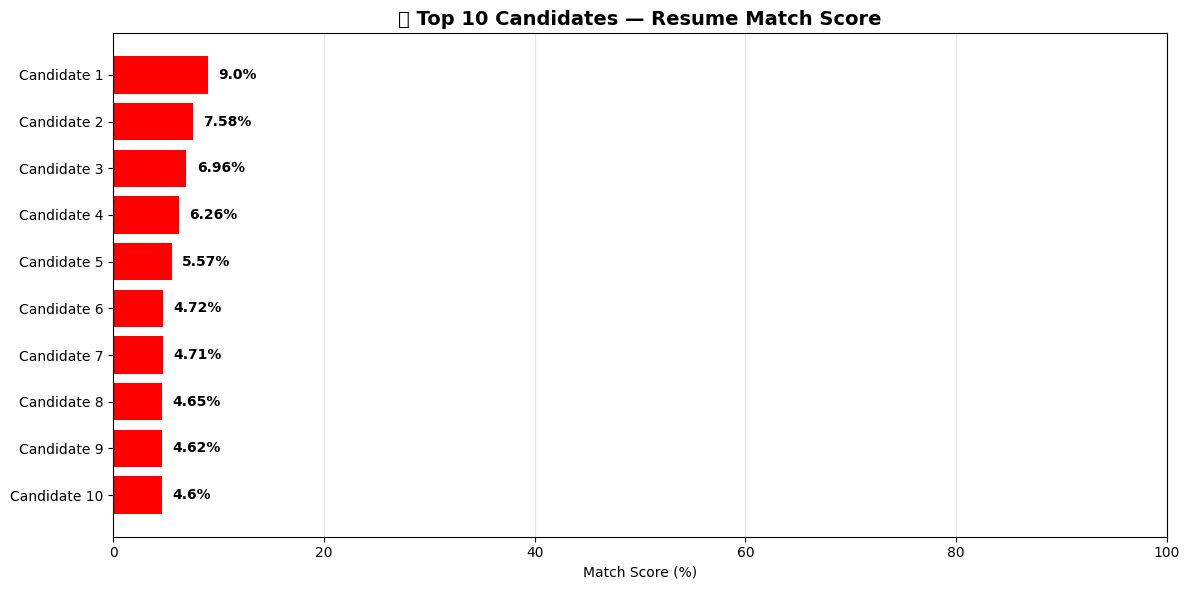

✅ Chart saved!


In [10]:
top10 = ranked.head(10)

plt.figure(figsize=(12, 6))
colors = ['green' if x >= 60 else 'orange' if x >= 40 else 'red'
          for x in top10['match_percent'].values]

bars = plt.barh(
    [f"Candidate {i}" for i in range(1, 11)],
    top10['match_percent'].values,
    color=colors)

plt.xlabel('Match Score (%)')
plt.title('🏆 Top 10 Candidates — Resume Match Score',
          fontsize=14, fontweight='bold')
plt.xlim(0, 100)
plt.gca().invert_yaxis()
plt.grid(axis='x', alpha=0.3)

for bar, val in zip(bars, top10['match_percent'].values):
    plt.text(val + 1, bar.get_y() + bar.get_height()/2,
             f'{val}%', va='center', fontweight='bold')

plt.tight_layout()
plt.savefig('candidate_ranking.png', dpi=150)
plt.show()
print("✅ Chart saved!")

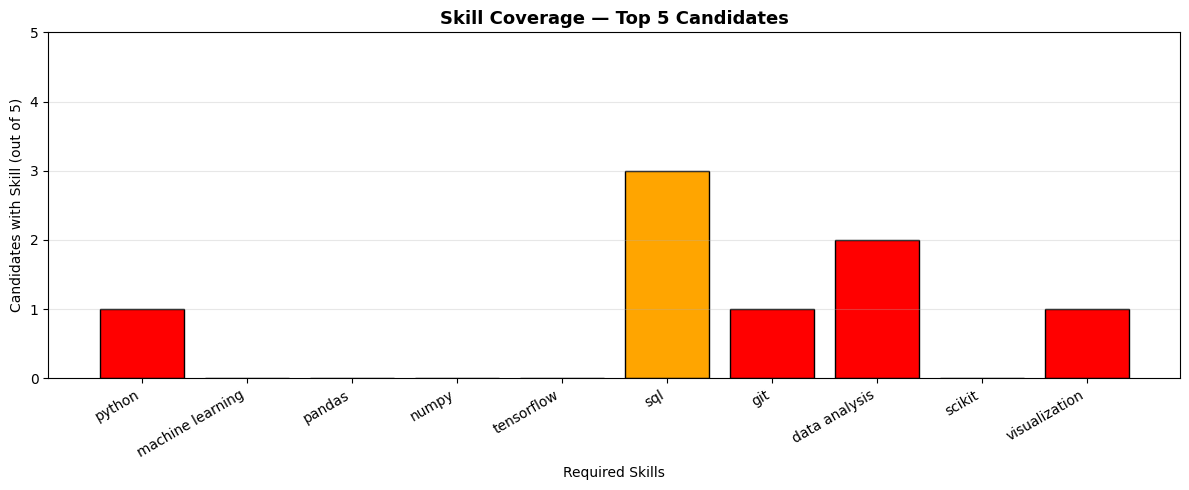

✅ Skill gap chart saved!


In [11]:
top5 = ranked.head(5)

skill_data = []
for skill in required_skills:
    count = sum(1 for resume in top5['clean_resume'] if skill in resume)
    skill_data.append({'Skill': skill, 'Count': count})

skill_df = pd.DataFrame(skill_data)

colors = ['green' if x == 5 else 'orange' if x >= 3 else 'red'
          for x in skill_df['Count']]

plt.figure(figsize=(12, 5))
plt.bar(skill_df['Skill'], skill_df['Count'],
        color=colors, edgecolor='black')
plt.title('Skill Coverage — Top 5 Candidates',
          fontsize=13, fontweight='bold')
plt.xlabel('Required Skills')
plt.ylabel('Candidates with Skill (out of 5)')
plt.xticks(rotation=30, ha='right')
plt.yticks(range(0, 6))
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('skill_gap.png', dpi=150)
plt.show()
print("✅ Skill gap chart saved!")

In [12]:
def screen_resume(resume_text):
    cleaned = clean_text(resume_text)
    combined = [clean_jd, cleaned]
    vec = TfidfVectorizer()
    matrix = vec.fit_transform(combined)
    score = cosine_similarity(matrix[0:1], matrix[1:2])[0][0] * 100

    print("=" * 50)
    print(f"🎯 Match Score : {score:.2f}%")
    if score >= 60:
        print("✅ Status      : SHORTLISTED")
    elif score >= 40:
        print("⚠️  Status      : MAYBE — Review Manually")
    else:
        print("❌ Status      : NOT SHORTLISTED")
    print("\n📋 Skill Check:")
    for skill in required_skills:
        status = '✅' if skill in cleaned else '❌'
        print(f"   {status} {skill}")
    print("=" * 50)

screen_resume("""
Experienced Python developer with 3 years in machine learning,
data analysis, pandas, numpy, scikit-learn, sql, git and github.
Strong problem solving and communication skills.
""")

🎯 Match Score : 61.98%
✅ Status      : SHORTLISTED

📋 Skill Check:
   ✅ python
   ✅ machine learning
   ✅ pandas
   ✅ numpy
   ❌ tensorflow
   ✅ sql
   ✅ git
   ✅ data analysis
   ✅ scikit
   ❌ visualization


In [13]:
shortlisted = len(ranked[ranked['match_percent'] >= 60])
maybe       = len(ranked[(ranked['match_percent'] >= 40) &
                          (ranked['match_percent'] < 60)])
rejected    = len(ranked[ranked['match_percent'] < 40])

print("=" * 55)
print("    RESUME SCREENING SYSTEM — BUSINESS SUMMARY")
print("=" * 55)
print(f"📄 Total Resumes Screened : {len(ranked)}")
print(f"✅ Shortlisted  (60%+)    : {shortlisted}")
print(f"⚠️  Maybe       (40-60%)   : {maybe}")
print(f"❌ Rejected     (<40%)     : {rejected}")
print(f"🏆 Top Score              : {ranked['match_percent'].iloc[0]}%")
print(f"📊 Average Score          : {ranked['match_percent'].mean():.2f}%")
print("-" * 55)
print("💡 Business Impact:")
print("   → Screens 100s of resumes in seconds")
print("   → Top candidates identified automatically")
print("   → Skill gaps flagged before interview")
print("   → Reduces recruiter workload by ~70%")
print("=" * 55)

    RESUME SCREENING SYSTEM — BUSINESS SUMMARY
📄 Total Resumes Screened : 120
✅ Shortlisted  (60%+)    : 0
⚠️  Maybe       (40-60%)   : 0
❌ Rejected     (<40%)     : 120
🏆 Top Score              : 9.0%
📊 Average Score          : 2.11%
-------------------------------------------------------
💡 Business Impact:
   → Screens 100s of resumes in seconds
   → Top candidates identified automatically
   → Skill gaps flagged before interview
   → Reduces recruiter workload by ~70%
